- Jitni vhi humne feature engineering kiya hai avhi tk you might have noticed that har column k alag alag problems hote hai
- kisi mei missing values hote hai, kisi ko scale krna ho, kisi mei categorical values hote hai, kisi mei numerical values hote hai
- In sb ko alag alag handle krna kaafi difficult hota hai

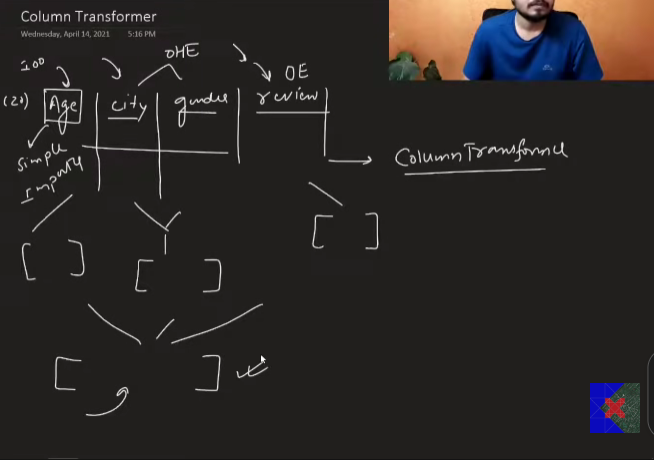

- Fo ex. in the pic above:
    - Age: numerical col (Simple imputation for filling values + scaling)
    - City: Nominal categorical col (OHE)
    - Gender: Nominal categorical col (OHE)
    - Review: Ordinal categorical col (Ordinal encoding)

- For age you will get a numpy array, for city and gender you will get a combined numpy array of OHE and for review you will get a numpy array of ordinal encoding. So, in the end you will have 3 different numpy arrays which you will have to combine together to create your final feature set. This can be quite cumbersome and error-prone, especially when dealing with large datasets and multiple features.

- So, isi ka solution hai ColumnTransformer -> jisse hume humare original dataframe se diect ek single line of code se final feature set mil jata hai, bina hume alag alag numpy arrays ko combine kre

In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.impute import SimpleImputer # to handle missing values
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [3]:
df = pd.read_csv('covid_toy.csv')

In [4]:
df.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


- Age, Fever: Numerical Columns
- Gender, City: Nominal Categorical Columns
- Cough: Ordinal Categorical Column

In [6]:
df['cough'].value_counts()

cough
Mild      62
Strong    38
Name: count, dtype: int64

In [7]:
df['city'].value_counts()

city
Kolkata      32
Bangalore    30
Delhi        22
Mumbai       16
Name: count, dtype: int64

In [8]:
df.isnull().sum() # to check for missing values

age           0
gender        0
fever        10
cough         0
city          0
has_covid     0
dtype: int64

- As fever have missing values, we will use simple imputation to fill those missing values.
- Gender: OHE
- City: OHE
- Cough: Ordinal encoding (as it is an ordinal categorical column)
- has_covid: LabelEncoding 

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['has_covid']),df['has_covid'],
                                                test_size=0.2)
# x has all the columns except target column ('has_covid')
# y has only target column

In [10]:
X_train

,age,gender,fever,cough,city
27,33,Female,102.0,Strong,Delhi
13,64,Male,102.0,Mild,Bangalore
19,42,Female,NaN,Strong,Bangalore
75,5,Male,102.0,Mild,Kolkata
86,25,Male,104.0,Mild,Bangalore
...,...,...,...,...,...
96,51,Female,101.0,Strong,Kolkata
48,66,Male,99.0,Strong,Bangalore
69,73,Female,103.0,Mild,Delhi
15,70,Male,103.0,Strong,Kolkata


## 1. Aam Zindagi (Without using ColumnTransformer)

In [ ]:
# adding simple imputer to fever col
si = SimpleImputer()
X_train_fever = si.fit_transform(X_train[['fever']]) # replace missing values in fever column with mean of that column, so here it is replaced by bean of X_train_fever column

# also the test data
X_test_fever = si.fit_transform(X_test[['fever']]) # And here it is replaced by mean of X_test_fever column
                                 
X_train_fever.shape

(80, 1)

In [12]:
X_train_fever

array([[102.        ],
       [102.        ],
       [100.74647887],
       [102.        ],
       [104.        ],
       [ 98.        ],
       [101.        ],
       [100.74647887],
       [100.74647887],
       [ 98.        ],
       [103.        ],
       [ 98.        ],
       [104.        ],
       [104.        ],
       [ 98.        ],
       [ 99.        ],
       [100.        ],
       [102.        ],
       [101.        ],
       [ 98.        ],
       [102.        ],
       [ 98.        ],
       [103.        ],
       [101.        ],
       [100.74647887],
       [102.        ],
       [ 99.        ],
       [104.        ],
       [ 98.        ],
       [100.        ],
       [ 98.        ],
       [104.        ],
       [102.        ],
       [ 99.        ],
       [100.        ],
       [100.        ],
       [ 98.        ],
       [100.74647887],
       [ 98.        ],
       [ 99.        ],
       [104.        ],
       [101.        ],
       [ 98.        ],
       [100

In [ ]:
# Ordinalencoding -> cough
oe = OrdinalEncoder(categories=[['Mild','Strong']])
X_train_cough = oe.fit_transform(X_train[['cough']])

# also the test data
#! X_test_cough = oe.fit_transform(X_test[['cough']])
#! Wrong code, as we did fit on train data, we should only transform the test data using the same oe object, not fit_transform
X_test_cough = oe.transform(X_test[['cough']])

X_train_cough.shape

(80, 1)

In [23]:
X_train_cough

array([[1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],

In [31]:
# OneHotEncoding -> gender,city
ohe = OneHotEncoder(drop='first',sparse_output=False)
X_train_gender_city = ohe.fit_transform(X_train[['gender','city']])

# also the test data
#! X_test_gender_city = ohe.fit_transform(X_test[['gender','city']])
#! Wrong code, as we did fit on train data, we should only transform the test data using the same ohe object, not fit_transform

X_test_gender_city = ohe.transform(X_test[['gender','city']])

X_train_gender_city.shape
# Gender has 2 categories -> 1 column after OHE (as we have used drop='first')
# City has 4 categories -> 3 columns after OHE (as we have used drop='first')
# Total 4 columns

(80, 4)

In [22]:
X_train_gender_city

array([[0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 0.],
       [1., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [1., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 1.],
       [1., 0., 1., 0.],
       [1., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 1., 0., 0.],
       [0., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 1., 0.],
       [1., 1., 0., 0.],
       [1., 0., 0., 1.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [1., 0., 1., 0.],
       [1., 0., 1., 0.],
       [1., 1., 0., 0.],
       [1., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [1., 1., 0., 0.],


In [19]:
X_train.drop(columns=['gender','fever','cough','city'])

,age
27,33
13,64
19,42
75,5
86,25
...,...
96,51
48,66
69,73
15,70


In [20]:
X_train.drop(columns=['gender','fever','cough','city']).values

array([[33],
       [64],
       [42],
       [ 5],
       [25],
       [65],
       [42],
       [75],
       [34],
       [83],
       [69],
       [73],
       [42],
       [51],
       [23],
       [59],
       [27],
       [82],
       [47],
       [26],
       [82],
       [31],
       [60],
       [19],
       [23],
       [24],
       [22],
       [16],
       [34],
       [27],
       [24],
       [34],
       [69],
       [60],
       [80],
       [13],
       [71],
       [20],
       [12],
       [65],
       [12],
       [83],
       [80],
       [11],
       [82],
       [27],
       [69],
       [38],
       [75],
       [16],
       [49],
       [11],
       [56],
       [20],
       [81],
       [83],
       [19],
       [55],
       [25],
       [47],
       [64],
       [71],
       [10],
       [65],
       [68],
       [14],
       [49],
       [49],
       [ 6],
       [ 5],
       [20],
       [74],
       [79],
       [64],
       [10],
       [51],
       [66],

In [21]:
# Extracting Age
X_train_age = X_train.drop(columns=['gender','fever','cough','city']).values

# also the test data
X_test_age = X_test.drop(columns=['gender','fever','cough','city']).values

X_train_age.shape

(80, 1)

In [ ]:
X_train_transformed = np.concatenate((X_train_age,X_train_fever,X_train_gender_city,X_train_cough),axis=1)
# also the test data
X_test_transformed = np.concatenate((X_test_age,X_test_fever,X_test_gender_city,X_test_cough),axis=1)

X_train_transformed.shape
# We had 1 column for age, 1 column for fever, 1 columns for gender, 3 columns for city and 1 column for cough
# Total 7 columns

(80, 7)

## Mentos Zindagi (Using ColumnTransformer)

In [25]:
from sklearn.compose import ColumnTransformer

In [27]:
# make an object of ColumnTransformer class
# The columns that we won't apply any transformation we will pass as it is using remainder='passthrough' or drop them using remainder='drop'
#/ Every transformation is showed using a tuple (name of transformation, object of transformation, list of columns to which we want to apply that transformation) 
transformer = ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(),['fever']),
    ('tnf2',OrdinalEncoder(categories=[['Mild','Strong']]),['cough']),
    ('tnf3',OneHotEncoder(sparse_output=False,drop='first'),['gender','city'])
],remainder='passthrough')

In [28]:
transformer.fit_transform(X_train).shape

(80, 7)

In [29]:
transformer.transform(X_test).shape

(20, 7)

## <span style="color:orange"> see the [transformation guide](./fit_vs_transform_guide.md) to see when to use fit() vs transform() methods</span>